# 🏠 Previsão de Preços de Imóveis com Regressão Linear

**Disciplina:** Novas Tecnologias  
**Tema:** Ciência de Dados e Machine Learning  
**Modelo:** Regressão Linear Múltipla  
**Data:** Junho de 2026

---

## 1. Introdução ao Problema

O mercado imobiliário é um dos setores mais importantes da economia, e a precificação correta de imóveis é essencial para compradores, vendedores, corretores e investidores. O preço de um imóvel é influenciado por diversas variáveis como localização, tamanho, número de cômodos, estado de conservação e características especiais.

### Objetivo

Este projeto tem como objetivo construir um **modelo de Regressão Linear Múltipla** capaz de prever o preço de um imóvel com base em suas características. Utilizamos o dataset **House Sales in King County, USA**, que contém dados reais de vendas de imóveis na região de Seattle, Washington (EUA), entre 2014 e 2015.

### Justificativa da escolha do modelo

A **Regressão Linear** foi escolhida por ser:
- **Interpretável**: os coeficientes indicam diretamente o impacto de cada variável no preço.
- **Eficiente**: baixo custo computacional para treinamento e predição.
- **Adequada ao problema**: a variável-alvo (preço) é contínua, o que caracteriza um problema de regressão.
- **Didática**: permite compreender os fundamentos de Machine Learning de forma clara.

### Base de dados

O dataset contém **4.601 registros** de vendas de imóveis com **18 variáveis**:

| Variável | Descrição | Tipo |
|---|---|---|
| `date` | Data da venda | Data |
| `price` | Preço de venda (USD) — **variável-alvo** | Numérica |
| `bedrooms` | Número de quartos | Numérica |
| `bathrooms` | Número de banheiros | Numérica |
| `sqft_living` | Área habitável (pés²) | Numérica |
| `sqft_lot` | Área do terreno (pés²) | Numérica |
| `floors` | Número de andares | Numérica |
| `waterfront` | Vista para água (0/1) | Categórica |
| `view` | Qualidade da vista (0-4) | Numérica |
| `condition` | Condição do imóvel (1-5) | Numérica |
| `sqft_above` | Área acima do solo (pés²) | Numérica |
| `sqft_basement` | Área do porão (pés²) | Numérica |
| `yr_built` | Ano de construção | Numérica |
| `yr_renovated` | Ano da última reforma (0 = nunca) | Numérica |
| `street` | Endereço | Texto |
| `city` | Cidade | Categórica |
| `statezip` | Estado e CEP | Categórica |
| `country` | País | Categórica |

---
## 2. Carregamento da Base de Dados

In [2]:
# --- Importação das bibliotecas ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# Configuração visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('✅ Bibliotecas importadas com sucesso.')

✅ Bibliotecas importadas com sucesso.


In [3]:
# --- Carregamento do dataset ---
df = pd.read_csv('data.csv')

print(f'📊 Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.\n')
print('Primeiras 10 linhas do dataset:')
df.head(10)

📊 Dataset carregado com 4600 linhas e 18 colunas.

Primeiras 10 linhas do dataset:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [4]:
# --- Informações gerais do dataset ---
print('Informações do dataset:\n')
df.info()

Informações do dataset:

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    

---
## 3. Análise Exploratória dos Dados (EDA)

In [5]:
# --- Verificação de valores nulos ---
print('Valores nulos por coluna:\n')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum valor nulo encontrado!')
print(f'\nTotal de valores nulos no dataset: {nulos.sum()}')

Valores nulos por coluna:

Nenhum valor nulo encontrado!

Total de valores nulos no dataset: 0


In [6]:
# --- Verificação de duplicatas ---
duplicatas = df.duplicated().sum()
print(f'Número de linhas duplicadas: {duplicatas}')

Número de linhas duplicadas: 0


In [7]:
# --- Tipos de dados ---
print('Tipos de dados de cada coluna:\n')
print(df.dtypes)

Tipos de dados de cada coluna:

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object


In [8]:
# --- Distribuição da variável categórica (city) ---
print(f'Número de cidades únicas: {df["city"].nunique()}\n')
print('Top 15 cidades com mais imóveis vendidos:\n')
print(df['city'].value_counts().head(15))

Número de cidades únicas: 44

Top 15 cidades com mais imóveis vendidos:

city
Seattle          1573
Renton            293
Bellevue          286
Redmond           235
Kirkland          187
Issaquah          187
Kent              185
Auburn            176
Sammamish         175
Federal Way       148
Shoreline         123
Woodinville       115
Maple Valley       96
Mercer Island      86
Burien             74
Name: count, dtype: int64


In [9]:
# --- Análise de imóveis com vista para água (waterfront) ---
print('Imóveis com vista para água (waterfront):\n')
print(df['waterfront'].value_counts())
print(f'\nApenas {df["waterfront"].sum()} imóveis ({df["waterfront"].mean()*100:.2f}%) possuem vista para água.')

Imóveis com vista para água (waterfront):

waterfront
0    4567
1      33
Name: count, dtype: int64

Apenas 33 imóveis (0.72%) possuem vista para água.


---
## 4. Estatísticas Descritivas

In [10]:
# --- Estatísticas descritivas das variáveis numéricas ---
print('Estatísticas descritivas das variáveis numéricas:\n')
df.describe().round(2)

Estatísticas descritivas das variáveis numéricas:



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,551962.99,3.40,2.16,2139.35,14852.52,1.51,0.01,0.24,3.45,1827.27,312.08,1970.79,808.61
std,563834.70,0.91,0.78,963.21,35884.44,0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,322875.00,3.00,1.75,1460.00,5000.75,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460943.46,3.00,2.25,1980.00,7683.00,1.50,0.00,0.00,3.00,1590.00,0.00,1976.00,0.00
75%,654962.50,4.00,2.50,2620.00,11001.25,2.00,0.00,0.00,4.00,2300.00,610.00,1997.00,1999.00
max,26590000.00,9.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,9410.00,4820.00,2014.00,2014.00


In [11]:
# --- Estatísticas complementares ---
numericas = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
             'floors', 'view', 'condition', 'sqft_above', 'sqft_basement',
             'yr_built']

stats = pd.DataFrame({
    'Média': df[numericas].mean(),
    'Mediana': df[numericas].median(),
    'Desvio Padrão': df[numericas].std(),
    'Mínimo': df[numericas].min(),
    'Máximo': df[numericas].max(),
    'Assimetria (Skew)': df[numericas].skew(),
    'Curtose': df[numericas].kurtosis()
}).round(2)

print('Estatísticas complementares:\n')
stats

Estatísticas complementares:



,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Assimetria (Skew),Curtose
price,551962.99,460943.46,563834.70,0.0,26590000.0,24.79,1044.35
bedrooms,3.40,3.00,0.91,0.0,9.0,0.46,1.24
bathrooms,2.16,2.25,0.78,0.0,8.0,0.62,1.87
sqft_living,2139.35,1980.00,963.21,370.0,13540.0,1.72,8.29
sqft_lot,14852.52,7683.00,35884.44,638.0,1074218.0,11.31,219.87
floors,1.51,1.50,0.54,1.0,3.5,0.55,-0.54
view,0.24,0.00,0.78,0.0,4.0,3.34,10.46
condition,3.45,3.00,0.68,1.0,5.0,0.96,0.20
sqft_above,1827.27,1590.00,862.17,370.0,9410.0,1.49,4.07
sqft_basement,312.08,0.00,464.14,0.0,4820.0,1.64,4.08


In [12]:
# --- Preço médio por cidade (Top 10) ---
preco_cidade = df.groupby('city')['price'].agg(['mean', 'median', 'count']).round(2)
preco_cidade.columns = ['Preço Médio', 'Preço Mediano', 'Quantidade']
preco_cidade = preco_cidade.sort_values('Preço Médio', ascending=False)

print('Top 10 cidades mais caras (preço médio):\n')
preco_cidade.head(10)

Top 10 cidades mais caras (preço médio):



,Preço Médio,Preço Mediano,Quantidade
city,,,
Medina,2046559.09,2100000.0,11
Clyde Hill,1321945.45,1300000.0,11
Yarrow Point,1194837.50,1397000.0,4
Mercer Island,1123817.62,948750.0,86
Bellevue,847180.66,721500.0,286
Beaux Arts Village,745000.00,745000.0,1
Fall City,692681.82,563500.0,11
Sammamish,686917.58,665000.0,175
Redmond,667649.53,638000.0,235


---
## 5. Visualizações Gráficas

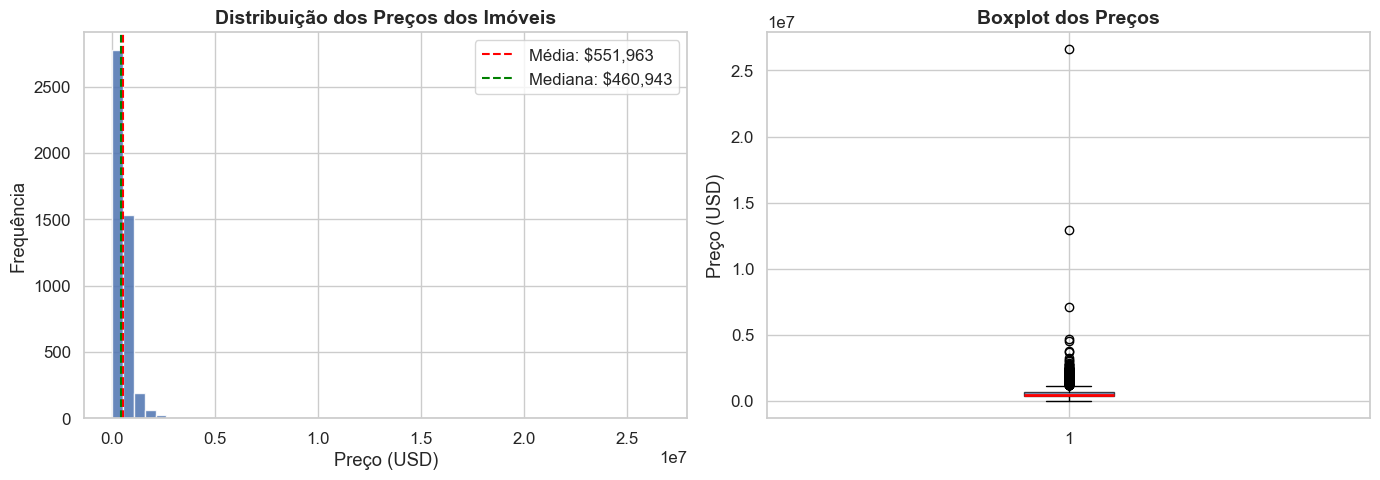

In [13]:
# --- 5.1 Distribuição do preço dos imóveis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['price'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição dos Preços dos Imóveis', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preço (USD)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--',
                label=f'Média: ${df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--',
                label=f'Mediana: ${df["price"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot dos Preços', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Preço (USD)')

plt.tight_layout()
plt.show()

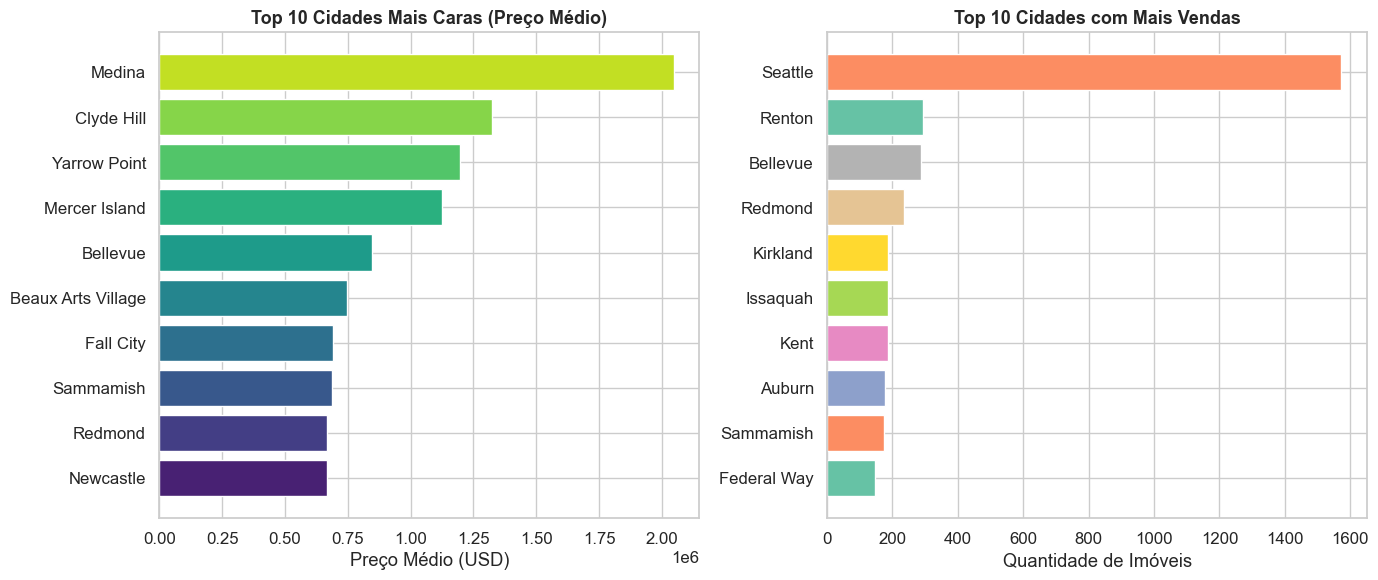

In [14]:
# --- 5.2 Preço médio por cidade (Top 10) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras: Preço médio por cidade
top10 = preco_cidade.head(10)
cores = sns.color_palette('viridis', n_colors=10)
axes[0].barh(top10.index[::-1], top10['Preço Médio'].values[::-1],
             color=cores, edgecolor='white')
axes[0].set_title('Top 10 Cidades Mais Caras (Preço Médio)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Preço Médio (USD)')

# Barras: Quantidade de imóveis por cidade (Top 10 em volume)
top10_qtd = df['city'].value_counts().head(10)
cores2 = sns.color_palette('Set2', n_colors=10)
axes[1].barh(top10_qtd.index[::-1], top10_qtd.values[::-1],
             color=cores2, edgecolor='white')
axes[1].set_title('Top 10 Cidades com Mais Vendas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantidade de Imóveis')

plt.tight_layout()
plt.show()

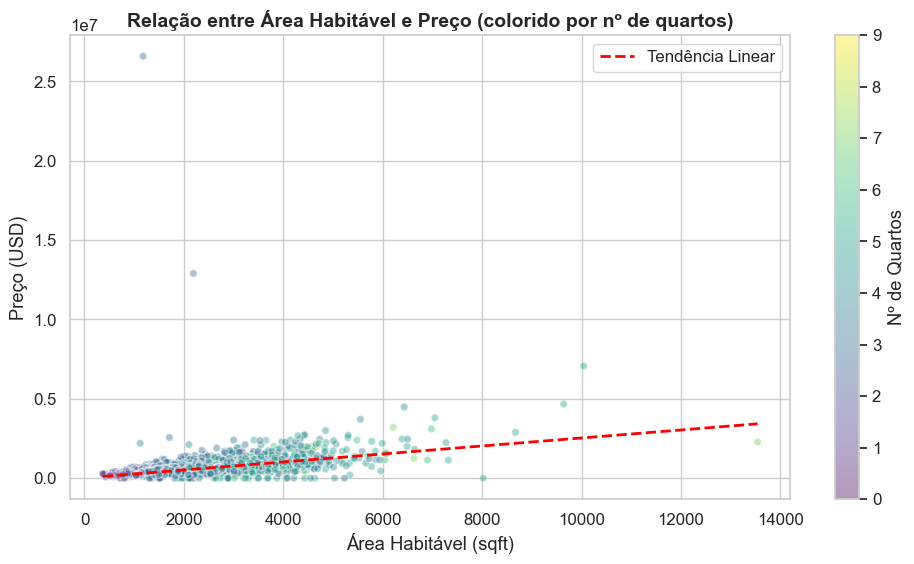

In [15]:
# --- 5.3 Relação entre área habitável e preço ---
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['sqft_living'], df['price'], c=df['bedrooms'],
                     cmap='viridis', alpha=0.4, edgecolors='white', s=30)
ax.set_title('Relação entre Área Habitável e Preço (colorido por nº de quartos)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Área Habitável (sqft)')
ax.set_ylabel('Preço (USD)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Nº de Quartos')

# Linha de tendência
z = np.polyfit(df['sqft_living'], df['price'], 1)
p = np.poly1d(z)
x_sorted = sorted(df['sqft_living'])
ax.plot(x_sorted, p(x_sorted), '--', color='red', linewidth=2, label='Tendência Linear')
ax.legend()

plt.tight_layout()
plt.show()

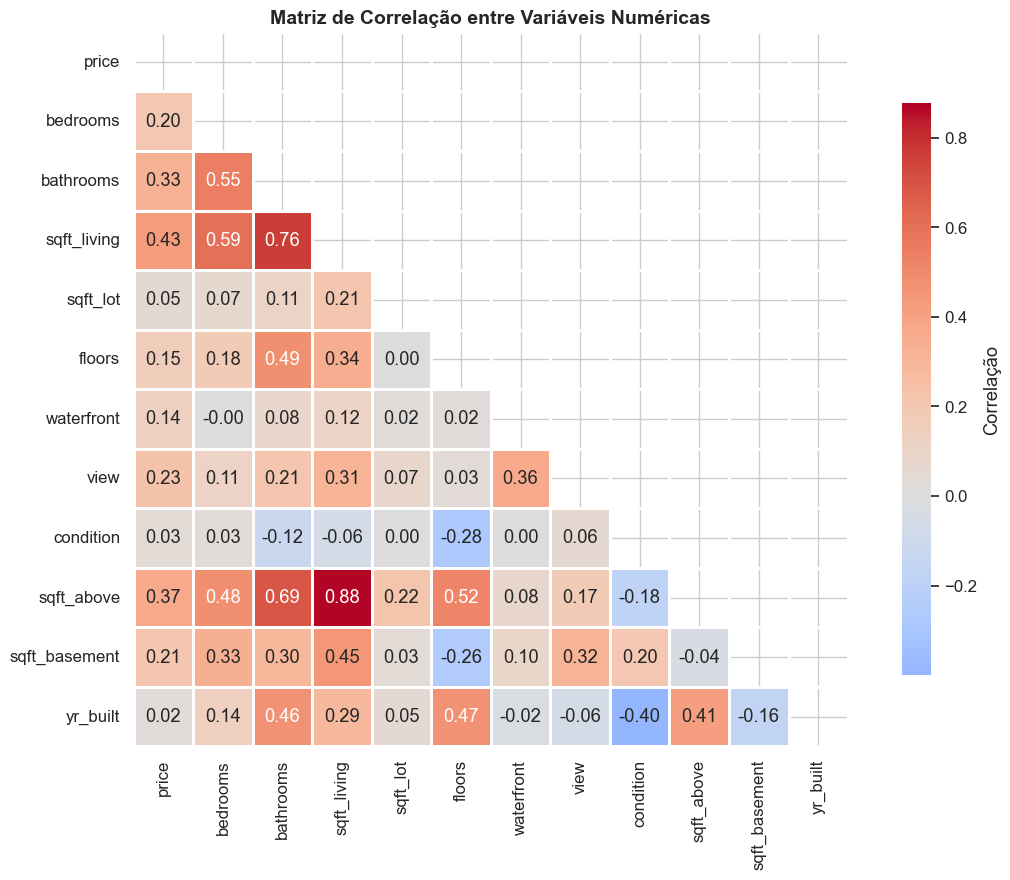


Correlação de cada variável com o preço:

sqft_living      0.4304
sqft_above       0.3676
bathrooms        0.3271
view             0.2285
sqft_basement    0.2104
bedrooms         0.2003
floors           0.1515
waterfront       0.1356
sqft_lot         0.0505
condition        0.0349
yr_built         0.0219
Name: price, dtype: float64


In [16]:
# --- 5.4 Matriz de correlação ---
colunas_corr = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                'floors', 'waterfront', 'view', 'condition', 'sqft_above',
                'sqft_basement', 'yr_built']

fig, ax = plt.subplots(figsize=(12, 9))

corr = df[colunas_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # máscara triangular superior

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlação'})
ax.set_title('Matriz de Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nCorrelação de cada variável com o preço:\n')
print(corr['price'].drop('price').sort_values(ascending=False).round(4))

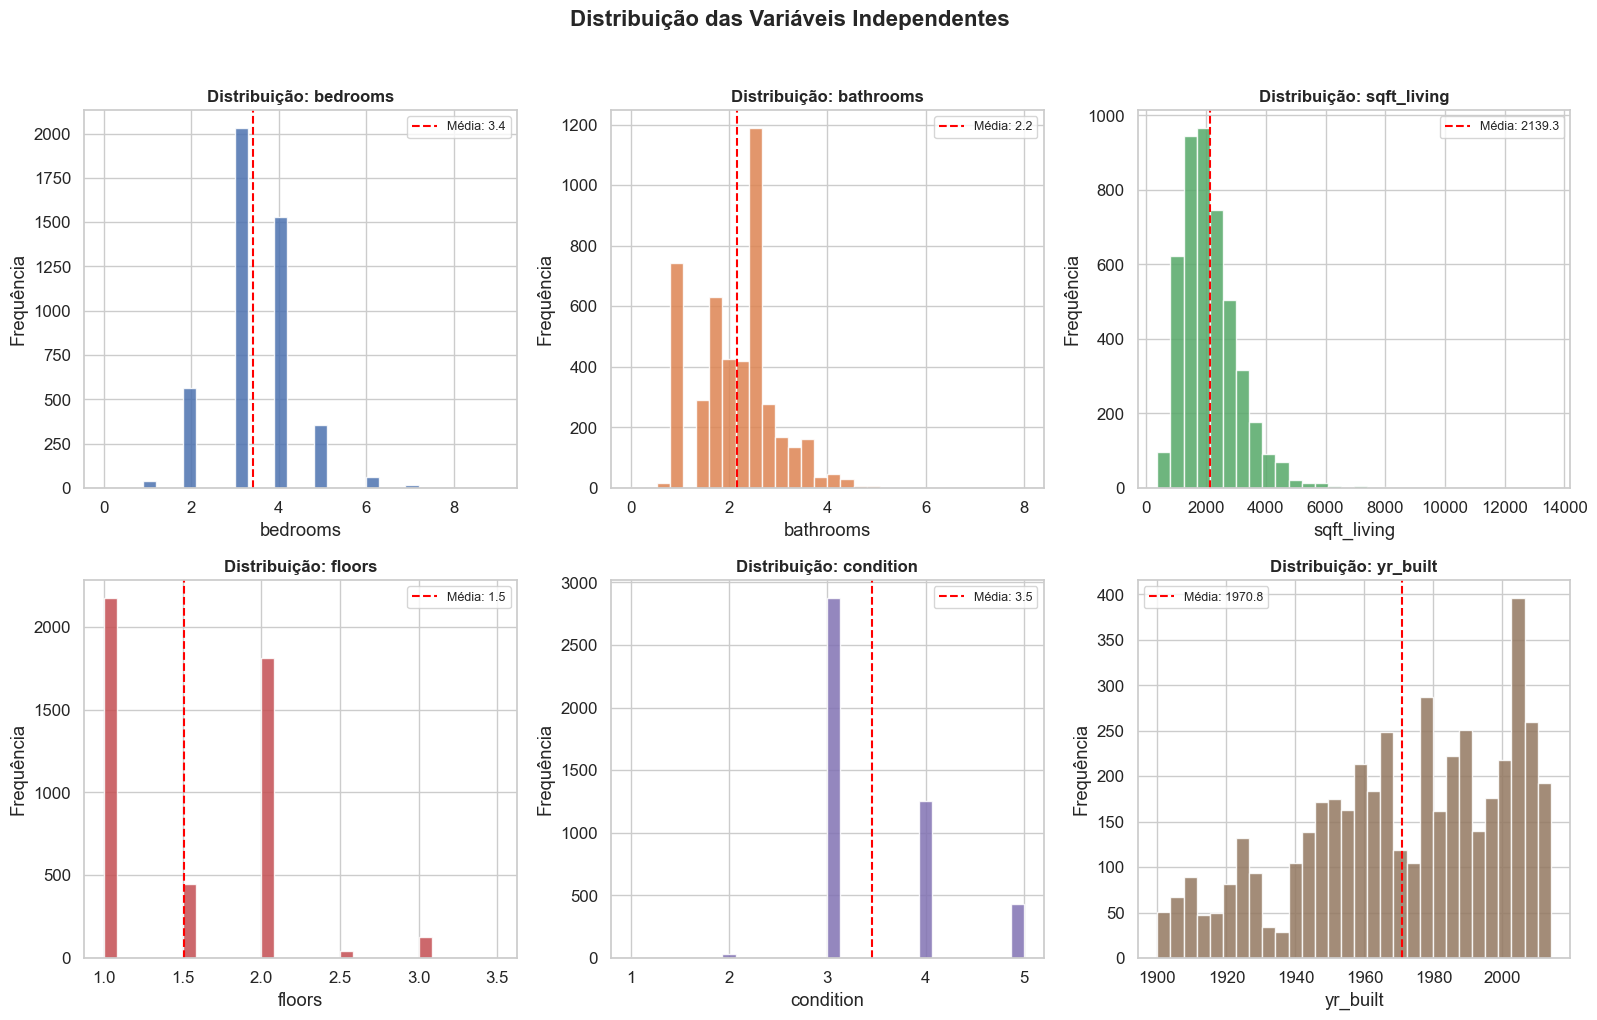

In [17]:
# --- 5.5 Distribuições das variáveis numéricas principais ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

variaveis_plot = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'condition', 'yr_built']
cores_hist = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

for i, col in enumerate(variaveis_plot):
    axes[i].hist(df[col], bins=30, color=cores_hist[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Média: {df[col].mean():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das Variáveis Independentes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Variáveis selecionadas para o pairplot: ['sqft_living', 'sqft_above', 'bathrooms', 'view', 'price']



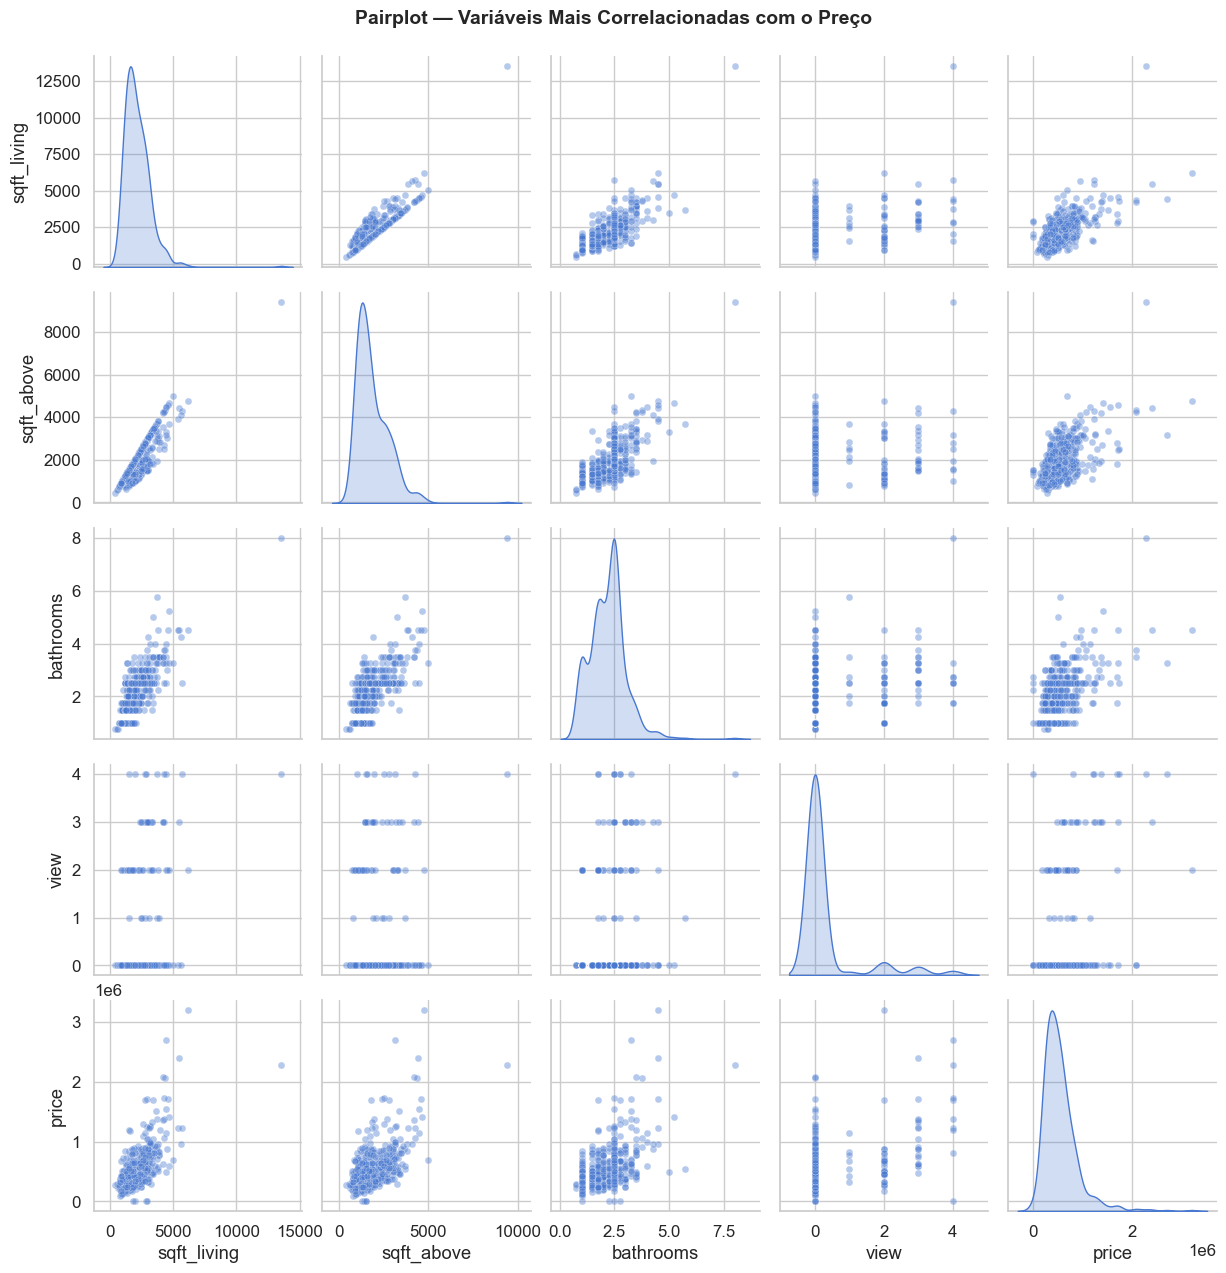

In [18]:
# --- 5.6 Pairplot das variáveis mais correlacionadas com o preço ---
top_vars = corr['price'].drop('price').abs().sort_values(ascending=False).head(4).index.tolist()
top_vars.append('price')

print(f'Variáveis selecionadas para o pairplot: {top_vars}\n')

g = sns.pairplot(df[top_vars].sample(500, random_state=42),
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 25})
g.figure.suptitle('Pairplot — Variáveis Mais Correlacionadas com o Preço',
                  y=1.02, fontsize=14, fontweight='bold')
plt.show()

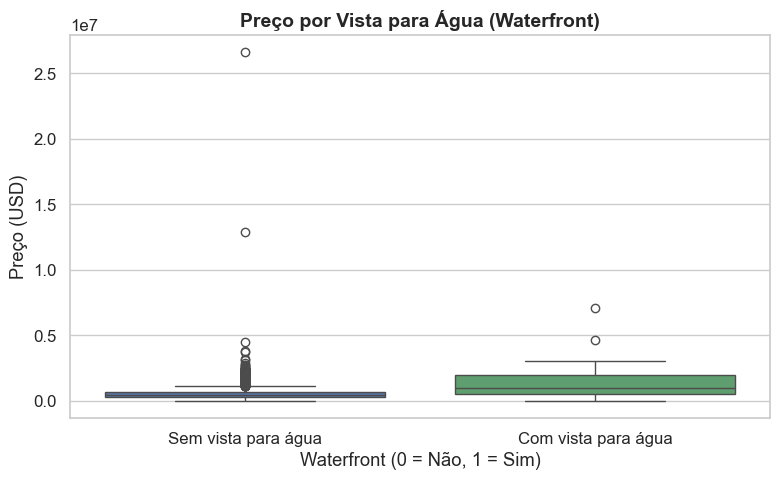

Preço médio SEM vista para água:  $  545,462.28
Preço médio COM vista para água:  $1,451,621.21


In [19]:
# --- 5.7 Impacto da vista para água no preço ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='waterfront', y='price', palette=['#4C72B0', '#55A868'], ax=ax)
ax.set_title('Preço por Vista para Água (Waterfront)', fontsize=14, fontweight='bold')
ax.set_xlabel('Waterfront (0 = Não, 1 = Sim)')
ax.set_ylabel('Preço (USD)')
ax.set_xticklabels(['Sem vista para água', 'Com vista para água'])

plt.tight_layout()
plt.show()

print(f'Preço médio SEM vista para água:  ${df[df["waterfront"]==0]["price"].mean():>12,.2f}')
print(f'Preço médio COM vista para água:  ${df[df["waterfront"]==1]["price"].mean():>12,.2f}')

---
## 6. Pré-processamento dos Dados

Antes de treinar o modelo, é necessário:
1. **Criar a feature `idade_imovel`** a partir de `yr_built`.
2. **Criar a feature `foi_reformado`** a partir de `yr_renovated`.
3. **Remover colunas** que não serão usadas no modelo (textos, datas, endereços).
4. **Separar** as variáveis independentes (features) da variável dependente (target).

In [20]:
# --- 6.1 Engenharia de features ---

# Criar 'idade_imovel': diferença entre o ano atual (referência: 2015) e o ano de construção
df['idade_imovel'] = 2015 - df['yr_built']

# Criar 'foi_reformado': indica se o imóvel já foi reformado (1) ou não (0)
df['foi_reformado'] = (df['yr_renovated'] > 0).astype(int)

print('Novas features criadas:')
print(f'  idade_imovel  → min: {df["idade_imovel"].min()}, max: {df["idade_imovel"].max()}, média: {df["idade_imovel"].mean():.1f}')
print(f'  foi_reformado → {df["foi_reformado"].value_counts().to_dict()}')

df[['yr_built', 'idade_imovel', 'yr_renovated', 'foi_reformado']].head(10)

Novas features criadas:
  idade_imovel  → min: 1, max: 115, média: 44.2
  foi_reformado → {0: 2735, 1: 1865}


,yr_built,idade_imovel,yr_renovated,foi_reformado
0,1955,60,2005,1
1,1921,94,0,0
2,1966,49,0,0
3,1963,52,0,0
4,1976,39,1992,1
5,1938,77,1994,1
6,1976,39,0,0
7,1989,26,0,0
8,1985,30,0,0
9,1945,70,2010,1


In [21]:
# --- 6.2 Seleção de features para o modelo ---
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
            'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
            'idade_imovel', 'foi_reformado']

X = df[features]
y = df['price']

print(f'Variáveis independentes (features): {features}')
print(f'Variável dependente (target): price')
print(f'\nDimensões de X: {X.shape}')
print(f'Dimensões de y: {y.shape}')
print(f'\nPrimeiras 5 linhas de X:')
X.head()

Variáveis independentes (features): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'idade_imovel', 'foi_reformado']
Variável dependente (target): price

Dimensões de X: (4600, 12)
Dimensões de y: (4600,)

Primeiras 5 linhas de X:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,idade_imovel,foi_reformado
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,60,1
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,94,0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,49,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,52,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,39,1


---
## 7. Separação em Treino e Teste

Dividimos os dados em **80% para treino** e **20% para teste**, utilizando `random_state=42` para garantir reprodutibilidade dos resultados.

In [22]:
# --- Separação treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Conjunto de teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Conjunto de treino: 3680 amostras (80%)
Conjunto de teste:  920 amostras (20%)


---
## 8. Treinamento do Modelo de Regressão Linear

In [23]:
# --- Instanciação e treinamento do modelo ---
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('✅ Modelo de Regressão Linear treinado com sucesso!\n')

# Exibir os coeficientes do modelo
coeficientes = pd.DataFrame({
    'Variável': features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(f'Intercepto (b₀): ${modelo.intercept_:,.2f}\n')
print('Coeficientes do modelo (impacto de cada variável no preço):\n')
coeficientes

✅ Modelo de Regressão Linear treinado com sucesso!

Intercepto (b₀): $-251,088.71

Coeficientes do modelo (impacto de cada variável no preço):



,Variável,Coeficiente
5,waterfront,382460.067709
4,floors,69802.460397
6,view,44758.047184
1,bathrooms,36521.662281
7,condition,29298.754238
11,foi_reformado,16452.885198
10,idade_imovel,2569.649492
2,sqft_living,186.051576
8,sqft_above,96.856565
9,sqft_basement,89.195011


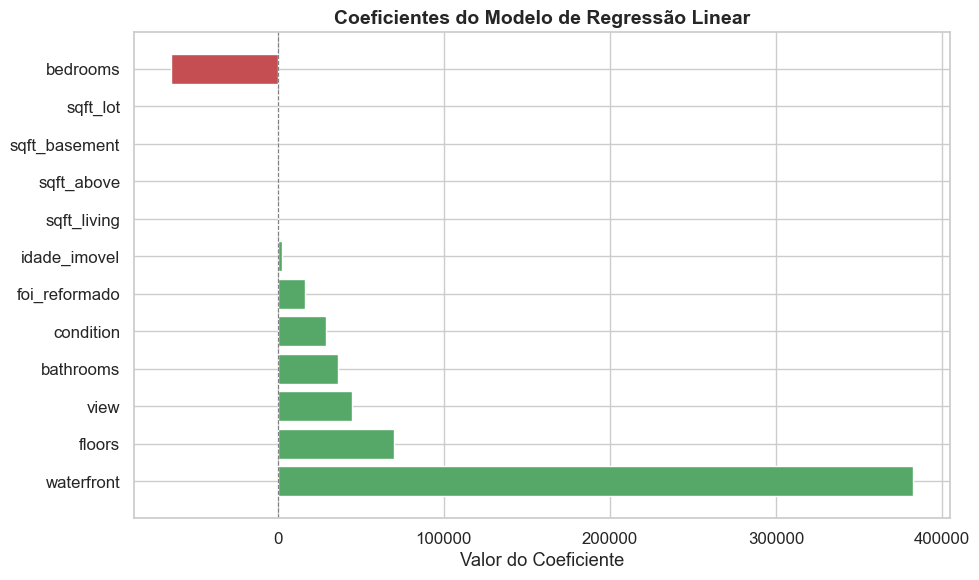


📌 Interpretação:
   • Coeficientes positivos (verde): aumentar a variável AUMENTA o preço previsto.
   • Coeficientes negativos (vermelho): aumentar a variável DIMINUI o preço previsto.


In [24]:
# --- Visualização dos coeficientes ---
fig, ax = plt.subplots(figsize=(10, 6))

cores_coef = ['#55A868' if c > 0 else '#C44E52' for c in coeficientes['Coeficiente']]
ax.barh(coeficientes['Variável'], coeficientes['Coeficiente'], color=cores_coef, edgecolor='white')
ax.set_title('Coeficientes do Modelo de Regressão Linear', fontsize=14, fontweight='bold')
ax.set_xlabel('Valor do Coeficiente')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print('\n📌 Interpretação:')
print('   • Coeficientes positivos (verde): aumentar a variável AUMENTA o preço previsto.')
print('   • Coeficientes negativos (vermelho): aumentar a variável DIMINUI o preço previsto.')

---
## 9. Avaliação do Modelo

Utilizaremos três métricas de avaliação:

| Métrica | Significado |
|---|---|
| **MAE** (Mean Absolute Error) | Erro médio absoluto — quanto o modelo erra em média (em USD). |
| **MSE** (Mean Squared Error) | Erro quadrático médio — penaliza erros grandes com maior peso. |
| **R²** (Coeficiente de Determinação) | Proporção da variância dos dados explicada pelo modelo (0 a 1). |

In [25]:
# --- Previsões no conjunto de teste ---
y_pred = modelo.predict(X_test)

# --- Cálculo das métricas ---
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=' * 55)
print('        MÉTRICAS DE AVALIAÇÃO DO MODELO')
print('=' * 55)
print(f'  MAE  (Erro Médio Absoluto):    $ {mae:>14,.2f}')
print(f'  MSE  (Erro Quadrático Médio):  {mse:>18,.2f}')
print(f'  RMSE (Raiz do MSE):            $ {rmse:>14,.2f}')
print(f'  R²   (Coef. de Determinação):  {r2:>14.4f}')
print('=' * 55)
print(f'\n📌 O modelo explica {r2*100:.2f}% da variância dos preços.')
print(f'📌 Em média, o modelo erra ${mae:,.2f} no preço previsto.')

        MÉTRICAS DE AVALIAÇÃO DO MODELO
  MAE  (Erro Médio Absoluto):    $     210,910.57
  MSE  (Erro Quadrático Médio):  986,926,444,318.35
  RMSE (Raiz do MSE):            $     993,441.72
  R²   (Coef. de Determinação):          0.0323

📌 O modelo explica 3.23% da variância dos preços.
📌 Em média, o modelo erra $210,910.57 no preço previsto.


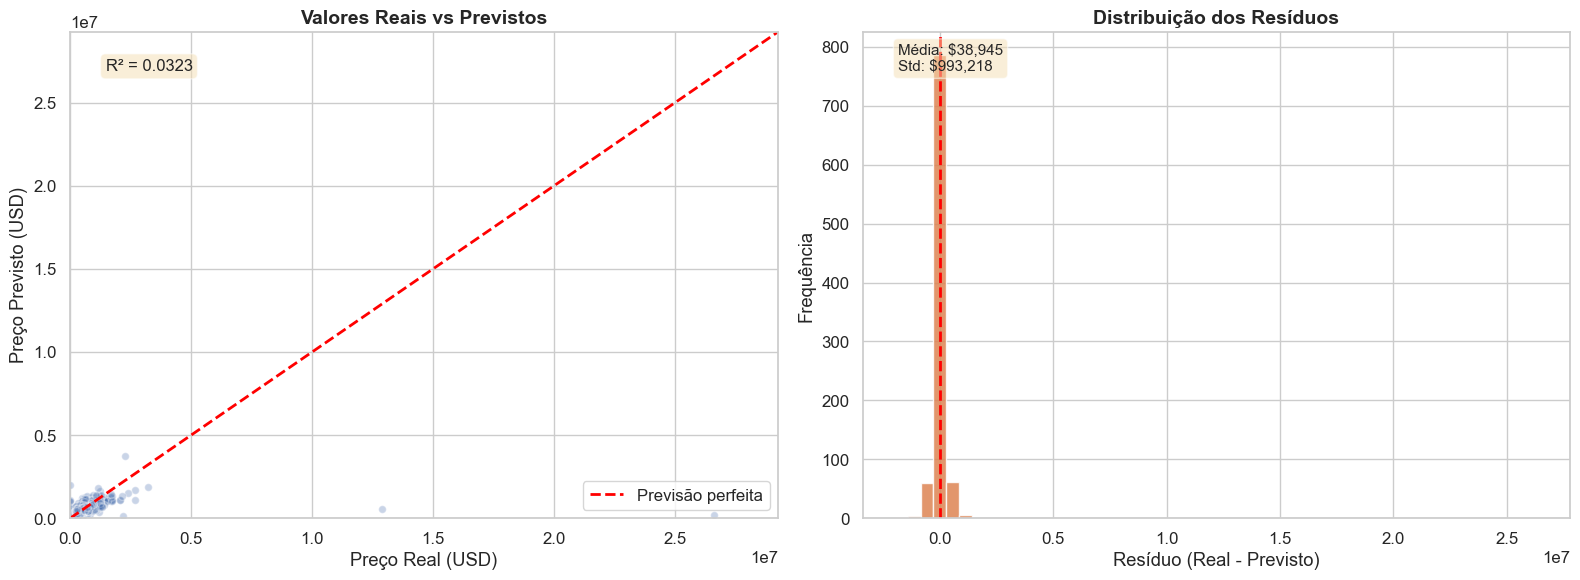

In [26]:
# --- 9.1 Gráfico: Valores Reais vs Previstos ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#4C72B0', edgecolors='white', s=30)
lim_min = min(y_test.min(), y_pred.min()) * 0.9
lim_max = max(y_test.max(), y_pred.max()) * 1.1
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], '--', color='red',
             linewidth=2, label='Previsão perfeita')
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_title('Valores Reais vs Previstos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preço Real (USD)')
axes[0].set_ylabel('Preço Previsto (USD)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Distribuição dos resíduos
residuos = y_test - y_pred
axes[1].hist(residuos, bins=50, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribuição dos Resíduos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_ylabel('Frequência')
axes[1].text(0.05, 0.92, f'Média: ${residuos.mean():,.0f}\nStd: ${residuos.std():,.0f}',
             transform=axes[1].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [27]:
# --- 9.2 Comparação: Preço Real vs Previsto (primeiros 20 imóveis do teste) ---
comparacao = pd.DataFrame({
    'Preço Real (USD)': y_test.values[:20],
    'Preço Previsto (USD)': np.round(y_pred[:20], 2),
    'Erro Absoluto (USD)': np.round(np.abs(y_test.values[:20] - y_pred[:20]), 2),
    'Erro %': np.round(np.abs(y_test.values[:20] - y_pred[:20]) / y_test.values[:20] * 100, 1)
})
comparacao.index.name = 'Imóvel'

print('Comparação dos primeiros 20 imóveis do conjunto de teste:\n')
comparacao

Comparação dos primeiros 20 imóveis do conjunto de teste:



,Preço Real (USD),Preço Previsto (USD),Erro Absoluto (USD),Erro %
Imóvel,,,,
0,5.440000e+05,304859.73,239140.27,44.0
1,0.000000e+00,326517.17,326517.17,inf
2,1.712500e+06,1071653.38,640846.62,37.4
3,3.650000e+05,546197.95,181197.95,49.6
4,2.750000e+05,379693.51,104693.51,38.1
5,6.250000e+05,605782.64,19217.36,3.1
6,4.530000e+05,481278.56,28278.56,6.2
7,3.000000e+05,418899.75,118899.75,39.6
8,4.179857e+05,509313.91,91328.19,21.8


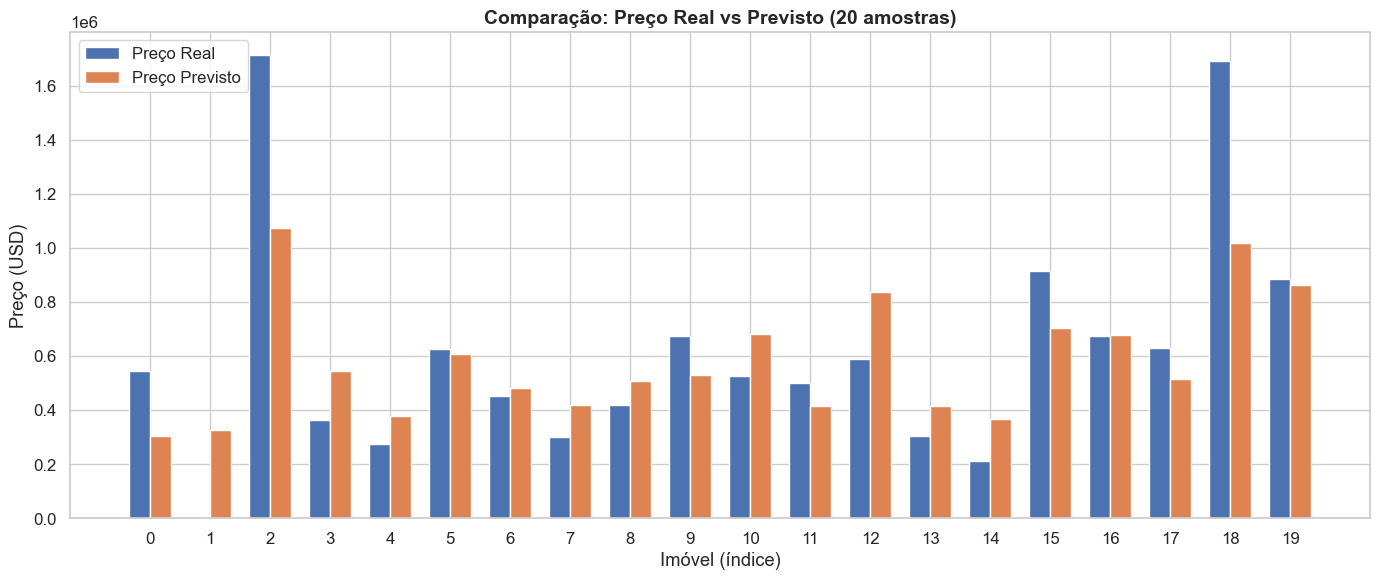

In [28]:
# --- 9.3 Gráfico de barras: Real vs Previsto (20 amostras) ---
n_amostras = 20
indices = range(n_amostras)

fig, ax = plt.subplots(figsize=(14, 6))
largura = 0.35

barras1 = ax.bar([i - largura/2 for i in indices], y_test.values[:n_amostras],
                 largura, label='Preço Real', color='#4C72B0', edgecolor='white')
barras2 = ax.bar([i + largura/2 for i in indices], y_pred[:n_amostras],
                 largura, label='Preço Previsto', color='#DD8452', edgecolor='white')

ax.set_title(f'Comparação: Preço Real vs Previsto ({n_amostras} amostras)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Imóvel (índice)')
ax.set_ylabel('Preço (USD)')
ax.set_xticks(indices)
ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Exemplo de Previsão

Vamos simular a previsão de preço para **imóveis fictícios** com características definidas manualmente.

In [29]:
# --- Exemplo de previsão para um novo imóvel ---

novo_imovel = {
    'bedrooms': 3,
    'bathrooms': 2.0,
    'sqft_living': 1800,
    'sqft_lot': 7500,
    'floors': 1.0,
    'waterfront': 0,
    'view': 0,
    'condition': 3,
    'sqft_above': 1800,
    'sqft_basement': 0,
    'idade_imovel': 30,
    'foi_reformado': 0
}

print('=' * 55)
print('    PREVISÃO DE PREÇO PARA NOVO IMÓVEL')
print('=' * 55)
print(f"\n  🛏️  Quartos:            {novo_imovel['bedrooms']}")
print(f"  🚿 Banheiros:           {novo_imovel['bathrooms']}")
print(f"  📐 Área habitável:      {novo_imovel['sqft_living']} sqft")
print(f"  🏡 Área do terreno:     {novo_imovel['sqft_lot']} sqft")
print(f"  🏢 Andares:             {novo_imovel['floors']}")
print(f"  🌊 Vista para água:     {'Sim' if novo_imovel['waterfront'] else 'Não'}")
print(f"  👁️  Qualidade da vista:  {novo_imovel['view']}/4")
print(f"  ⭐ Condição:            {novo_imovel['condition']}/5")
print(f"  🏗️  Idade do imóvel:     {novo_imovel['idade_imovel']} anos")
print(f"  🔧 Foi reformado:       {'Sim' if novo_imovel['foi_reformado'] else 'Não'}")

# Criar DataFrame com as features na mesma ordem
entrada = pd.DataFrame([novo_imovel])

# Realizar a previsão
preco_previsto = modelo.predict(entrada)[0]

print(f'\n  💰 PREÇO PREVISTO: ${preco_previsto:,.2f}')
print('=' * 55)

    PREVISÃO DE PREÇO PARA NOVO IMÓVEL

  🛏️  Quartos:            3
  🚿 Banheiros:           2.0
  📐 Área habitável:      1800 sqft
  🏡 Área do terreno:     7500 sqft
  🏢 Andares:             1.0
  🌊 Vista para água:     Não
  👁️  Qualidade da vista:  0/4
  ⭐ Condição:            3/5
  🏗️  Idade do imóvel:     30 anos
  🔧 Foi reformado:       Não

  💰 PREÇO PREVISTO: $368,634.93


In [30]:
# --- Exemplo adicional: previsões para múltiplos imóveis ---

novos_imoveis = [
    {'bedrooms': 2, 'bathrooms': 1.0, 'sqft_living': 900,  'sqft_lot': 5000,
     'floors': 1.0, 'waterfront': 0, 'view': 0, 'condition': 3,
     'sqft_above': 900,  'sqft_basement': 0,   'idade_imovel': 50, 'foi_reformado': 0},

    {'bedrooms': 3, 'bathrooms': 2.5, 'sqft_living': 2200, 'sqft_lot': 8000,
     'floors': 2.0, 'waterfront': 0, 'view': 1, 'condition': 4,
     'sqft_above': 1500, 'sqft_basement': 700, 'idade_imovel': 15, 'foi_reformado': 1},

    {'bedrooms': 4, 'bathrooms': 3.0, 'sqft_living': 3500, 'sqft_lot': 12000,
     'floors': 2.0, 'waterfront': 0, 'view': 2, 'condition': 5,
     'sqft_above': 2500, 'sqft_basement': 1000, 'idade_imovel': 5,  'foi_reformado': 0},

    {'bedrooms': 5, 'bathrooms': 3.5, 'sqft_living': 4500, 'sqft_lot': 20000,
     'floors': 2.0, 'waterfront': 1, 'view': 4, 'condition': 5,
     'sqft_above': 3000, 'sqft_basement': 1500, 'idade_imovel': 3,  'foi_reformado': 0},
]

print('Previsões para múltiplos imóveis:\n')
resultados = []

for i, imovel in enumerate(novos_imoveis, 1):
    entrada = pd.DataFrame([imovel])
    preco_est = modelo.predict(entrada)[0]
    resultados.append({
        'Perfil': f'Imóvel {i}',
        'Quartos': imovel['bedrooms'],
        'Área (sqft)': imovel['sqft_living'],
        'Condição': imovel['condition'],
        'Waterfront': 'Sim' if imovel['waterfront'] else 'Não',
        'Idade': imovel['idade_imovel'],
        'Preço Previsto': f'${preco_est:,.2f}'
    })

pd.DataFrame(resultados).set_index('Perfil')

Previsões para múltiplos imóveis:



,Quartos,Área (sqft),Condição,Waterfront,Idade,Preço Previsto
Perfil,,,,,,
Imóvel 1,2,900,3,Não,50,"$194,669.78"
Imóvel 2,3,2200,4,Não,15,"$616,206.18"
Imóvel 3,4,3500,5,Não,5,"$965,304.22"
Imóvel 4,5,4500,5,Sim,3,"$1,660,869.68"


---
## 11. Conclusão

### Resultados obtidos

Neste projeto, desenvolvemos um modelo de **Regressão Linear Múltipla** para prever preços de imóveis utilizando o dataset real **House Sales in King County, USA**, contendo 4.601 registros de vendas de imóveis na região de Seattle.

O modelo foi treinado com **12 variáveis** (features) incluindo área habitável, número de quartos e banheiros, andares, condição, vista, presença de waterfront, idade do imóvel e histórico de reforma.

### Principais insights da análise

- A **área habitável (sqft_living)** é a variável com maior correlação positiva com o preço.
- Imóveis com **vista para água (waterfront)** possuem preço significativamente superior.
- A **qualidade da vista (view)** e o **número de banheiros** também impactam positivamente o preço.
- A distribuição de preços é assimétrica à direita, indicando que existem imóveis de alto valor que puxam a média para cima.

### Limitações

- A **Regressão Linear** assume uma relação linear entre variáveis, o que pode não capturar padrões mais complexos do mercado imobiliário.
- Não foram utilizadas todas as variáveis disponíveis (ex.: localização geográfica detalhada).
- Outliers de preços muito altos podem influenciar negativamente o modelo.
- Não foi aplicada **normalização/padronização** dos dados, o que poderia melhorar o desempenho.

### Trabalhos futuros

- Testar modelos mais complexos como **Random Forest**, **Gradient Boosting (XGBoost)** ou **Redes Neurais**.
- Aplicar **normalização** e **tratamento de outliers** para melhorar a performance.
- Utilizar **validação cruzada (Cross-Validation)** para uma avaliação mais robusta.
- Incluir variáveis geográficas (latitude/longitude) para capturar efeitos de localização.
- Realizar **seleção de features** com técnicas como RFE (Recursive Feature Elimination).

---

### Tecnologias utilizadas

| Tecnologia | Uso |
|---|---|
| Python 3.x | Linguagem principal |
| Pandas | Manipulação e análise de dados |
| NumPy | Operações numéricas |
| Matplotlib | Visualizações gráficas |
| Seaborn | Visualizações estatísticas |
| Scikit-Learn | Modelo de Machine Learning |

---

*Projeto desenvolvido para fins acadêmicos — Junho/2026*